Here I am looking only geometric distriptors by using Nitrogen Nitrogen distances and min-Heavy atom distances to test the KRR model

In [11]:
# ===============================
# 0. IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold, cross_validate
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.metrics import make_scorer, mean_squared_error
from sklearn.kernel_ridge import KernelRidge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
import joblib
import os

Convert coupling_eV to log_coupling by adding small alpha for zero coupling

In [17]:
import numpy as np
import pandas as pd

# 1. Load your master dataset
input_path = "../data/NN_distance/my_dataset.csv"
df = pd.read_csv(input_path)

# 2. Define your dynamic shift factor (slightly below the 2.72114E-06 minimum)
alpha = 2e-6  

# 3. Apply the shift-log transformation to handle the 67 exact zero couplings
df["log10_Coupling"] = np.log10(df["Coupling_eV"] + alpha)
target = "log10_Coupling"

# Verify the transformation boundaries
zero_count = (df["Coupling_eV"] == 0).sum()
print(f"Successfully processed {len(df)} samples.")
print(f"Mapped {zero_count} zero-coupling points to a floor of {df['log10_Coupling'].min():.4f}")

# 4. Save the dataset to your specified output file path
output_path = "../data/NN_distance/808_alpha_shift_dataset.csv"
df.to_csv(output_path, index=False)

print(f"Saved shift-transformed dataset to: {output_path}")

Successfully processed 808 samples.
Mapped 67 zero-coupling points to a floor of -5.6990
Saved shift-transformed dataset to: ../data/NN_distance/808_alpha_shift_dataset.csv


Feature Correlation Plot

Correlation matrix:
                    log10_Coupling_eV  FeFe_Dist_Ang  NN_Dist_1_Ang  \
log10_Coupling_eV           1.000000      -0.334782      -0.440936   
FeFe_Dist_Ang              -0.334782       1.000000       0.857715   
NN_Dist_1_Ang              -0.440936       0.857715       1.000000   
NN_Dist_2_Ang              -0.429494       0.912290       0.938330   
NN_Dist_3_Ang              -0.408637       0.953475       0.931508   
NN_Dist_4_Ang              -0.406415       0.965684       0.910740   
NN_Dist_5_Ang              -0.335266       0.973237       0.902589   
NN_Dist_6_Ang              -0.320663       0.988872       0.879673   
NN_Dist_7_Ang              -0.334863       0.991145       0.879708   
NN_Dist_8_Ang              -0.356088       0.991984       0.871950   
NN_Dist_9_Ang              -0.350506       0.988521       0.862777   
NN_Dist_10_Ang             -0.334478       0.988712       0.844551   
NN_Dist_11_Ang             -0.328042       0.987014       0.825889   

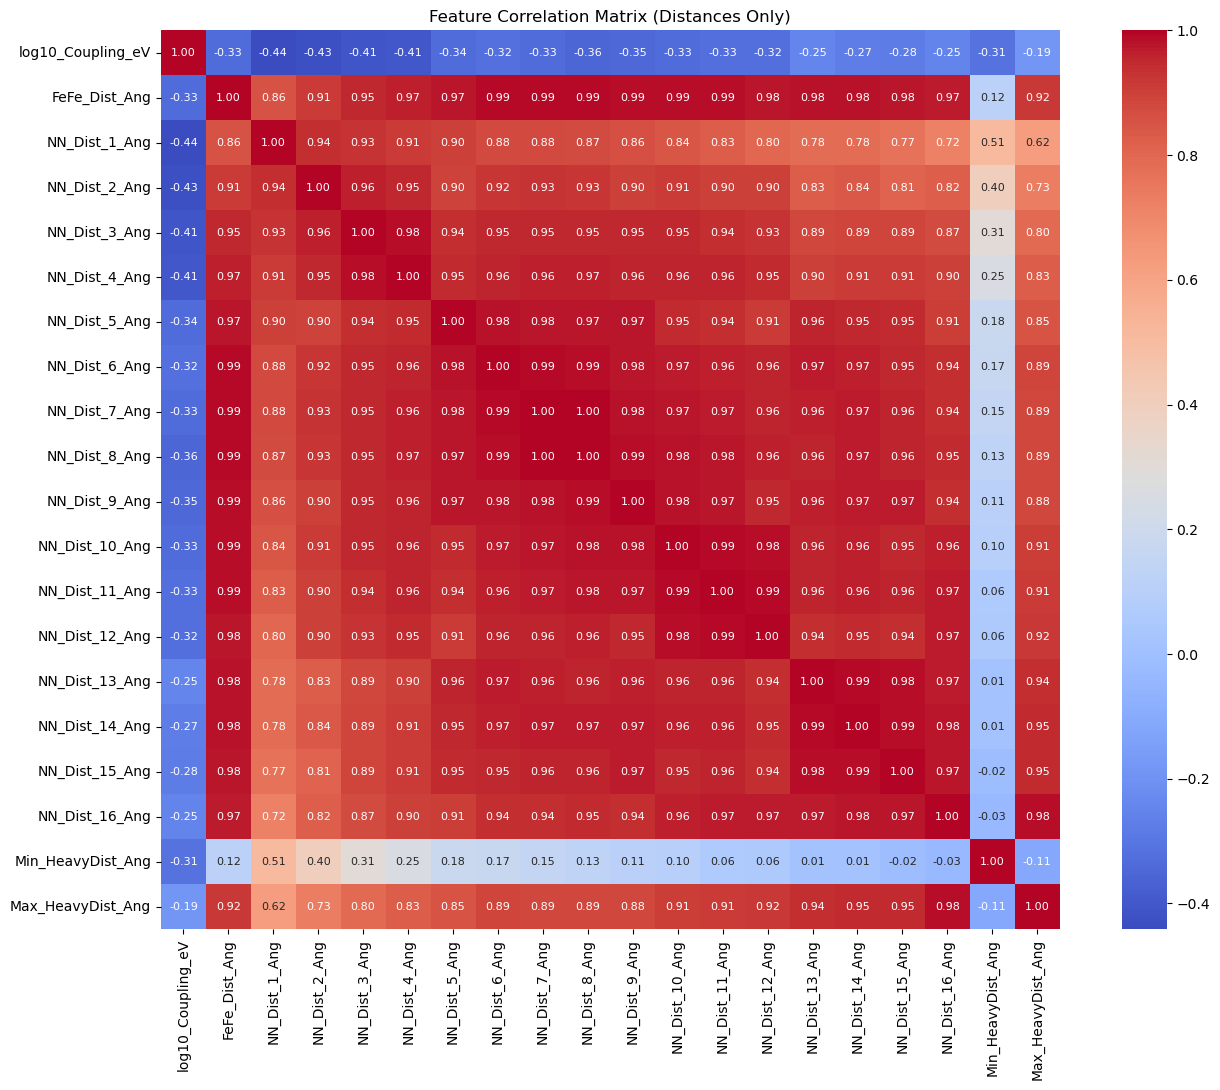

<Figure size 640x480 with 0 Axes>

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("../data/NN_distance/808_alpha_shift_dataset.csv")

# Target processing
alpha = 2e-6
df["log10_Coupling_eV"] = np.log10(df["Coupling_eV"] + alpha)

# 1. Dynamically generate the 16 N-N distance columns
nn_dist_cols = [f"NN_Dist_{i}_Ang" for i in range(1, 17)]

# 2. Set up your specific feature list
# Target + Fe-Fe distance + 16 N-N distances + Min/Max heavy atom distances
X_cols = ["log10_Coupling_eV", "FeFe_Dist_Ang"] + nn_dist_cols + ["Min_HeavyDist_Ang", "Max_HeavyDist_Ang"]

corr_cols = X_cols

# Subset and drop rows with NaNs in these columns
corr_df = df[corr_cols].dropna()

# Compute correlation matrix
corr_matrix = corr_df.corr()

print("Correlation matrix:\n", corr_matrix)

# Plot heatmap (increased figure size slightly to accommodate 20 total variables clearly)
plt.figure(figsize=(14, 11))
sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            cbar=True,
            square=True,
            annot_kws={"size": 8}) # Slightly smaller text inside cells for readability

plt.title("Feature Correlation Matrix (Distances Only)")
plt.tight_layout()
# Create the directory path safely
output_dir = "../data/NN_distance/Figure"
import os
os.makedirs(output_dir, exist_ok=True)

# Save heatmap into the verified directory
plt.savefig(f"{output_dir}/808_alphashift_log10_coupling_eV_distances_only_correlation.png",
            dpi=300,
            bbox_inches="tight")
plt.show()
# Save heatmap
plt.savefig(f"{output_dir}/808_alphashift_log10_coupling_NN_distances_only_correlation.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

KRR MODEL TRAINING BASED ON NN DISTACNE

In [21]:

df = pd.read_csv("../data/NN_distance/808_alpha_shift_dataset.csv")
# Test Setup A vs all features
features = ["NN_Dist_1_Ang","NN_Dist_2_Ang", "NN_Dist_3_Ang", "NN_Dist_4_Ang","NN_Dist_13_Ang","NN_Dist_14_Ang","NN_Dist_15_Ang","NN_Dist_16_Ang", "Min_HeavyDist_Ang"]  # "NN_Dist_12_Ang","FeFe_Dist_Ang", "NN_Dist_4_Ang",, "Max_HeavyDist_Ang"
#all_features = [col for col in X_cols if col != "log10_Coupling_eV"]

# Set alpha slightly smaller than your minimum value (2.72114e-06)
#alpha = 2e-6  
# Apply the transformation
#df["log10_Coupling"] = np.log10(df["Coupling_eV"] + alpha)
target = "log10_Coupling"
#target = ["Coupling_eV"]
#target = "log10_J_cdft"
# keep only rows where features and Coupling_eV are present
df = df.dropna(subset=features + [target])

# keep only higher couplings: Coupling_eV > 1e-4
df = df[df["log10_Coupling"] > -4].copy()
#df = df[df["log10_J_cdft"] > -4].copy()
print(f"Number of samples : {len(df)}")

X = df[features]
y = df[target]

#Startification for train/test split
df["coupling_bin"] = pd.qcut(
    df["log10_Coupling"],
    q=10,
    duplicates="drop"
)

#from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["coupling_bin"],
    random_state=42
)

X_train = train_df[features].values
#y_train = train_df["log10_J_cdft"].values
y_train = train_df[target].values
y_bins = train_df["coupling_bin"].cat.codes  # 🔑 reuse bins

# X_train = train_df[features].values
# y_train = train_df[target].values

X_test  = test_df[features].values
y_test  = test_df[target].values
""" Here train on high coupling and test on both (low+high) coupling states here
# =====================================================================
# 🟢 INSERT NEW SCRIPT HERE: Filter Training Set Only for High Coupling (> 1e-4)
# =====================================================================
# Calculate the log10 value for your 1e-4 threshold after the alpha shift
#Threshold = log10(1e-4 + 2e-6)
test_threshold = -5  # log10(1e-4) = -4, since alpha is negligible at this threshold

# Create a boolean mask for the training data rows that are above this threshold
#high_coupling_mask = y_train > train_threshold
high_coupling_mask = y_test > test_threshold
# Overwrite X_train and y_train with only the high coupling data
# X_train = X_train[high_coupling_mask]
# y_train = y_train[high_coupling_mask]
# y_bins = y_bins[high_coupling_mask] # Update bins if you use them in your CV splits
X_test = X_test[high_coupling_mask]
y_test = y_test[high_coupling_mask]
print(f"Filtered Training set size: {len(X_train)} samples")
print(f"Untouched Test set size: {len(X_test)} samples (includes all couplings)")
 Ends here"""

# 2️⃣ Prepare stratified splits manually
#from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_splits = list(skf.split(X_train, y_bins))  # now works correctly
# ===============================
# 3. CREATE OUTPUT DIR
# ===============================
# Results_dir = "../Results"
# os.makedirs(Results_dir, exist_ok=True)

# ===============================
# 4. KRR MODEL AND PARAMS
# ===============================
model_name = "Kernel Ridge"

# Pipeline with scaling + KRR
model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KernelRidge())
])

param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10],
    "model__gamma": [0.001, 0.01, 0.1, 1, 10],
    "model__kernel": ["rbf"]
}

# 4️⃣ Grid search with stratified CV
grid = GridSearchCV(
    model,
    param_grid,
    #cv = 5,
    cv=cv_splits,  # use the stratified splits
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)
KRR_best_model = grid.best_estimator_

print("Best parameters:", grid.best_params_)

# After grid search CV
#===============================
# Prepare test set
# ===============================
# X_test = test_df[features].values
# y_test = test_df["Coupling_eV"].values

results_list = []

# ===============================
# Cross-validation loop
# ===============================
for fold, (train_idx, val_idx) in enumerate(cv_splits):

    model = clone(KRR_best_model)
    model.fit(X_train[train_idx], y_train[train_idx])

    # Predictions
    y_pred_train = model.predict(X_train[train_idx])
    y_pred_val   = model.predict(X_train[val_idx])
    y_pred_test  = model.predict(X_test)

    # ===============================
    # Metrics
    # ===============================
    train_mae = mean_absolute_error(y_train[train_idx], y_pred_train)
    train_r2  = r2_score(y_train[train_idx], y_pred_train)

    val_mae   = mean_absolute_error(y_train[val_idx], y_pred_val)
    val_r2    = r2_score(y_train[val_idx], y_pred_val)

    test_mae  = mean_absolute_error(y_test, y_pred_test)
    test_r2   = r2_score(y_test, y_pred_test)

    # Print
    print(f"Fold {fold+1}:")
    print(f"  Train MAE = {train_mae:.5f}, R² = {train_r2:.5f}")
    print(f"  Val   MAE = {val_mae:.5f}, R² = {val_r2:.5f}")
    print(f"  Test  MAE = {test_mae:.5f}, R² = {test_r2:.5f}")

    # Store results
    results_list.append({
        "Fold": fold + 1,
        "Train_MAE": train_mae,
        "Train_R2": train_r2,
        "Val_MAE": val_mae,
        "Val_R2": val_r2,
        "Test_MAE": test_mae,
        "Test_R2": test_r2
    })

# ===============================
# Convert to DataFrame
# ===============================
results_df = pd.DataFrame(results_list)

# ===============================
# Compute Mean & Std
# ===============================
mean_row = {"Fold": "Mean"}
std_row  = {"Fold": "Std"}

for col in results_df.columns[1:]:
    mean_row[col] = results_df[col].mean()
    std_row[col]  = results_df[col].std()

results_df = pd.concat(
    [results_df, pd.DataFrame([mean_row, std_row])],
    ignore_index=True
)

# ===============================
# Save CSV
# ===============================
save_path = os.path.join(
    output_dir, "674_krr_stratified_both_cv_9NN_feat_threshold_results.csv"
)

results_df.to_csv(save_path, index=False)

print(f"\nResults saved to: {save_path}")

# ===============================
# Pretty Print Summary
# ===============================
print("\n=== Model Performance Stratified CV (Mean ± Std) ===")

print(f"Train MAE = {mean_row['Train_MAE']:.5f} ± {std_row['Train_MAE']:.5f}")
print(f"Train R²  = {mean_row['Train_R2']:.5f} ± {std_row['Train_R2']:.5f}")

print(f"Val   MAE = {mean_row['Val_MAE']:.5f} ± {std_row['Val_MAE']:.5f}")
print(f"Val   R²  = {mean_row['Val_R2']:.5f} ± {std_row['Val_R2']:.5f}")

print(f"Test  MAE = {mean_row['Test_MAE']:.5f} ± {std_row['Test_MAE']:.5f}")
print(f"Test  R²  = {mean_row['Test_R2']:.5f} ± {std_row['Test_R2']:.5f}")

Number of samples : 674
Best parameters: {'model__alpha': 0.01, 'model__gamma': 0.1, 'model__kernel': 'rbf'}
Fold 1:
  Train MAE = 0.23476, R² = 0.79450
  Val   MAE = 0.26489, R² = 0.70771
  Test  MAE = 0.33064, R² = 0.54186
Fold 2:
  Train MAE = 0.21463, R² = 0.82433
  Val   MAE = 0.36509, R² = 0.50323
  Test  MAE = 0.32745, R² = 0.54823
Fold 3:
  Train MAE = 0.22730, R² = 0.81190
  Val   MAE = 0.30268, R² = 0.59732
  Test  MAE = 0.31512, R² = 0.57969
Fold 4:
  Train MAE = 0.22172, R² = 0.80644
  Val   MAE = 0.30271, R² = 0.57514
  Test  MAE = 0.31356, R² = 0.56121
Fold 5:
  Train MAE = 0.22180, R² = 0.81202
  Val   MAE = 0.33950, R² = 0.58990
  Test  MAE = 0.31039, R² = 0.59617

Results saved to: ../data/NN_distance/Figure/674_krr_stratified_both_cv_9NN_feat_threshold_results.csv

=== Model Performance Stratified CV (Mean ± Std) ===
Train MAE = 0.22404 ± 0.00749
Train R²  = 0.80984 ± 0.01079
Val   MAE = 0.31497 ± 0.03848
Val   R²  = 0.59466 ± 0.07340
Test  MAE = 0.31943 ± 0.00901
Tes

TO SAVE PKL MODEL

In [22]:
import pickle

# ===============================
# SAVE MODEL & DATA FOR PARITY PLOT
# ===============================
# Ensure Results_dir is defined (matching your commented path)
Results_dir = "../data/NN_distance" 
os.makedirs(Results_dir, exist_ok=True)

# 1. Generate final predictions using your best KRR model on the test set
# (Alternatively, you can save the predictions made during your last CV fold)
y_pred_test_final = KRR_best_model.predict(X_test)

# 2. Package everything you need for the parity plot into a single dictionary
plot_data = {
    "model_name": "Kernel Ridge Regression",
    "best_params": grid.best_params_,
    "features": features,
    "X_test": X_test,
    "y_true": y_test,
    "y_pred": y_pred_test_final,
    "best_model": KRR_best_model  # Saves the actual trained pipeline (scaler + model)
}

# 3. Define the pickle save path
pkl_save_path = os.path.join(
    Results_dir,
    "krr_9feat_674_data.pkl"
)

# 4. Write to disk
with open(pkl_save_path, "wb") as f:
    pickle.dump(plot_data, f)

print(f"Parity plot data and trained model successfully saved to: {pkl_save_path}")

Parity plot data and trained model successfully saved to: ../data/NN_distance/krr_9feat_674_data.pkl


Parity plot

In [23]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, r2_score

# =====================================================================
# 1. SETUP PATHS AND LOAD DATA
# =====================================================================
Results_dir = "../data/NN_distance"
pkl_save_path = os.path.join(Results_dir, "krr_9feat_674_data.pkl")

if not os.path.exists(pkl_save_path):
    raise FileNotFoundError(f"Could not find the pickle file at: {pkl_save_path}")

with open(pkl_save_path, "rb") as f:
    saved_data = pickle.load(f)

# Extract variables from your saved dictionary
best_model = saved_data["best_model"]
X_test = saved_data["X_test"]
y_test_true = saved_data["y_true"]

# Note: If your previous training script didn't save X_train/y_train in the pkl, 
# this plot will focus beautifully on the Test Set performance. 
# We'll generate the final predictions here to ensure absolute alignment.
y_test_pred = best_model.predict(X_test)

# Calculate final test metrics for the plot legend/text box
test_mae = mean_absolute_error(y_test_true, y_test_pred)
test_r2 = r2_score(y_test_true, y_test_pred)

# =====================================================================
# 2. PLOT CONFIGURATION (Publication Quality)
# =====================================================================
sns.set_theme(style="ticks")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 12

fig, ax = plt.subplots(figsize=(6, 5.5), dpi=300)

# Scatter plot for Test Data
ax.scatter(
    y_test_true, 
    y_test_pred, 
    c="#1f77b4",          # Professional blue
    alpha=0.7, 
    edgecolors="w", 
    linewidths=0.5, 
    s=50, 
    label=f"Test Set (N={len(y_test_true)})"
)

# =====================================================================
# 3. ADD THE AXIS limits AND PERFECT PARITY LINE (Y = X)
# =====================================================================
# Dynamically determine limits based on data range
min_val = min(y_test_true.min(), y_test_pred.min()) - 0.3
max_val = max(y_test_true.max(), y_test_pred.max()) + 0.3

ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)

# Ideal 45-degree parity line
ax.plot(
    [min_val, max_val], [min_val, max_val], 
    color="#d62728",     # Muted red line
    linestyle="--", 
    linewidth=1.5, 
    label="Perfect Prediction"
)

# =====================================================================
# 4. LABELS, LEGEND, AND METRICS TEXT BOX
# =====================================================================
ax.set_xlabel(r"True $\log_{10}(\mathrm{Coupling} + \alpha)$ [eV]", fontsize=13, fontweight="bold")
ax.set_ylabel(r"Predicted $\log_{10}(\mathrm{Coupling} + \alpha)$ [eV]", fontsize=13, fontweight="bold")
ax.set_title("Kernel Ridge Regression: Coupling Parity 674 9 NN_distance feature", fontsize=14, fontweight="bold", pad=15)

# Metrics text box overlay
stats_text = f"Test MAE: {test_mae:.3f}\nTest $R^2$: {test_r2:.3f}"
bbox_props = dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray", alpha=0.85)
ax.text(
    0.05, 0.95, 
    stats_text, 
    transform=ax.transAxes, 
    fontsize=11,
    verticalalignment="top", 
    bbox=bbox_props
)

# Grid and Legend layout
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend(loc="lower right", frameon=True, facecolor="white", edgecolor="none")

# Clean up layout margins
plt.tight_layout()

# =====================================================================
# 5. SAVE GRAPH
# =====================================================================
plot_save_path = os.path.join(Results_dir, "krr_coupling_9feat_674_parity_plot.png")
plt.savefig(plot_save_path, bbox_inches="tight")
plt.close()

print(f"Parity plot successfully generated and saved to: {plot_save_path}")

Parity plot successfully generated and saved to: ../data/NN_distance/krr_coupling_9feat_674_parity_plot.png


SIDE BY SIDE VALUE DISTRIBUTION AND RESIDUAL DISTRIBUTION PLOT

In [15]:
# =====================================================================
# 6. SIDE-BY-SIDE DISTRIBUTION PLOTS
# =====================================================================
print("Generating side-by-side distribution plots...")

# Create a figure with 1 row and 2 columns
fig_dist, axs = plt.subplots(1, 2, figsize=(12, 5), dpi=300)

# ---------------------------------------------------------------------
# Plot 1 (Left): True vs. Predicted Overlap
# ---------------------------------------------------------------------
sns.histplot(
    y_test_true,
    kde=True,
    stat="density",
    color="#1f77b4",          # True data blue
    alpha=0.3,
    linewidth=1.5,
    label="True Values",
    ax=axs[0]
)

sns.histplot(
    y_test_pred,
    kde=True,
    stat="density",
    color="#ff7f0e",          # Predicted data orange
    alpha=0.3,
    linewidth=1.5,
    label="Predicted Values",
    ax=axs[0]
)

axs[0].set_xlabel(r"$\log_{10}(\mathrm{Coupling} + \alpha)$ [eV]", fontsize=12, fontweight="bold")
axs[0].set_ylabel("Probability Density", fontsize=12, fontweight="bold")
axs[0].set_title("(a) Value Distributions", fontsize=13, fontweight="bold", pad=10)
axs[0].grid(True, linestyle=":", alpha=0.6)
axs[0].legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none", fontsize=10)

# ---------------------------------------------------------------------
# Plot 2 (Right): Residuals Distribution (Errors)
# ---------------------------------------------------------------------
residuals = y_test_true - y_test_pred

sns.histplot(
    residuals,
    kde=True,
    stat="density",
    color="#2ca02c",          # Professional green for errors
    alpha=0.4,
    linewidth=1.5,
    ax=axs[1]
)

# Add a vertical line at 0 to show ideal error center
axs[1].axvline(0, color="#d62728", linestyle="--", linewidth=1.5, label="Zero Error")

axs[1].set_xlabel(r"Residual Error [$\Delta\log_{10}(\mathrm{Coupling})$]", fontsize=12, fontweight="bold")
axs[1].set_ylabel("Probability Density", fontsize=12, fontweight="bold")
axs[1].set_title("(b) Residuals Distribution 5 feat NN 674", fontsize=13, fontweight="bold", pad=10)
axs[1].grid(True, linestyle=":", alpha=0.6)
axs[1].legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none", fontsize=10)

# Make lines thicker for presentation visibility
for ax in axs:
    for line in ax.lines:
        line.set_linewidth(2.5)

# Clean up structural layout margins
plt.tight_layout()

# =====================================================================
# 7. SAVE SIDE-BY-SIDE GRAPH
# =====================================================================
side_by_side_save_path = os.path.join(Results_dir, "krr_coupling_5feat_674_side_distribution_plots.png")
plt.savefig(side_by_side_save_path, bbox_inches="tight")
plt.close()

print(f"Side-by-side distribution plots successfully saved to: {side_by_side_save_path}")

Generating side-by-side distribution plots...
Side-by-side distribution plots successfully saved to: ../data/NN_distance/krr_coupling_5feat_674_side_distribution_plots.png
